In [5]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import pandas as pd
import numpy as np

df_0_1 = pd.read_csv('/content/drive/MyDrive/ai & ml/mnist_0_and_1.csv')

X = df_0_1.drop(columns=["label"]).values
y = df_0_1["label"].values

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


What does shape of X represent?

12665 → number of images (samples)
784 → number of features (pixels in 28×28 image)

What does shape of y represent?

12665 → number of labels (one for each image)

In [2]:
def MCP_Neurons_AND(X1, X2, T):

    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        total = X1[i] + X2[i]

        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2

result = MCP_Neurons_AND(X1, X2, T)

print(result)


[0, 0, 0, 1]


3.1 Write OR Function

In [3]:
def MCP_Neurons_OR(X1, X2, T):

    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        total = X1[i] + X2[i]

        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


3.2 Test OR Function

In [4]:
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1

result_or = MCP_Neurons_OR(X1, X2, T)

print(result_or)


[0, 1, 1, 1]


Limitations of MCP:

No learning capability

Fixed weights and threshold

Cannot solve non-linear problems

Cannot solve XOR

Only works for simple logic

XOR Answer:

MCP cannot solve XOR because it is not linearly separable

Needs multiple neurons (multi-layer)

#Visualize the Dataset(Digits 0 and 1)

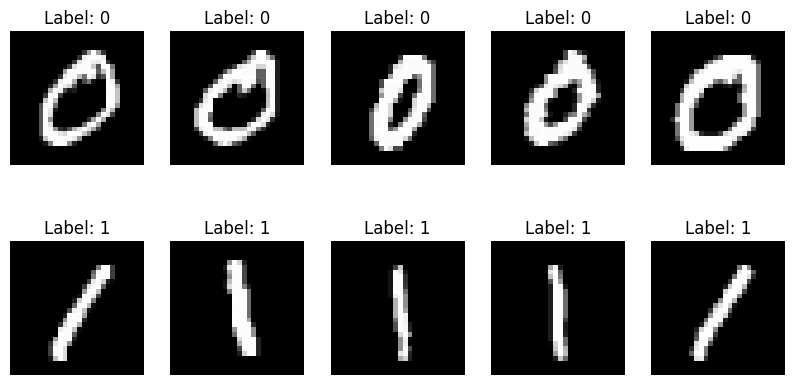

In [6]:
import matplotlib.pyplot as plt

images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 0")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 1")
    axes[1, i].axis("off")

plt.show()

#initialize weights

In [7]:
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100

Weights represent importance of each pixel
Initialized to zero as starting point

#Decision Function

In [8]:
def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias
    return np.where(predictions >= 0, 1, 0)

#Train Perception

In [9]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):

    for epoch in range(epochs):
        for i in range(len(X)):

            output = np.dot(X[i], weights) + bias
            y_pred = 1 if output >= 0 else 0

            if y_pred != y[i]:
                weights = weights + learning_rate * (y[i] - y_pred) * X[i]
                bias = bias + learning_rate * (y[i] - y_pred)

    y_final = decision_function(X, weights, bias)
    accuracy = np.mean(y_final == y)

    return weights, bias, accuracy

#Accuracy

In [10]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Final Accuracy:", accuracy)

Final Accuracy: 1.0


#Misclassified images

In [11]:
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

misclassified_idx = np.where(y_pred != y)[0]

print("Number of misclassified:", len(misclassified_idx))

Number of misclassified: 0


In [12]:
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.show()
else:
    print("All images were correctly classified!")

All images were correctly classified!


#3 vs 5

In [13]:
import pandas as pd
import numpy as np

df_3_5 = pd.read_csv('/content/drive/MyDrive/ai & ml/mnist_3_and_5.csv')

X_35 = df_3_5.drop(columns=["label"]).values
y_35 = df_3_5["label"].values

print("Feature matrix shape:", X_35.shape)
print("Label vector shape:", y_35.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


#Visualize

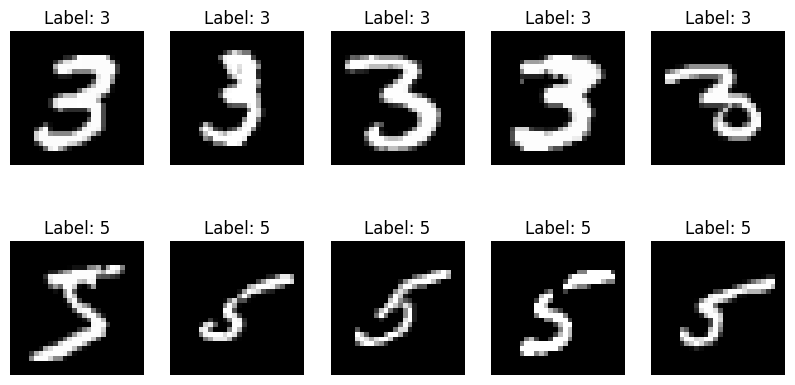

In [14]:
import matplotlib.pyplot as plt

images_3 = X_35[y_35 == 3]
images_5 = X_35[y_35 == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 3")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 5")
    axes[1, i].axis("off")

plt.show()

#Convert Labes and initialize weights


In [15]:
y_35 = np.where(y_35 == 3, 0, 1)

In [16]:
weights = np.zeros(X_35.shape[1])
bias = 0

#Resue train perceptron

In [17]:
weights, bias, accuracy = train_perceptron(X_35, y_35, weights, bias)

print("Final Accuracy (3 vs 5):", accuracy)

Final Accuracy (3 vs 5): 0.986866107260124


#Misclassified Images

In [18]:
predictions = np.dot(X_35, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

misclassified_idx = np.where(y_pred != y_35)[0]

print("Number of misclassified:", len(misclassified_idx))

Number of misclassified: 36


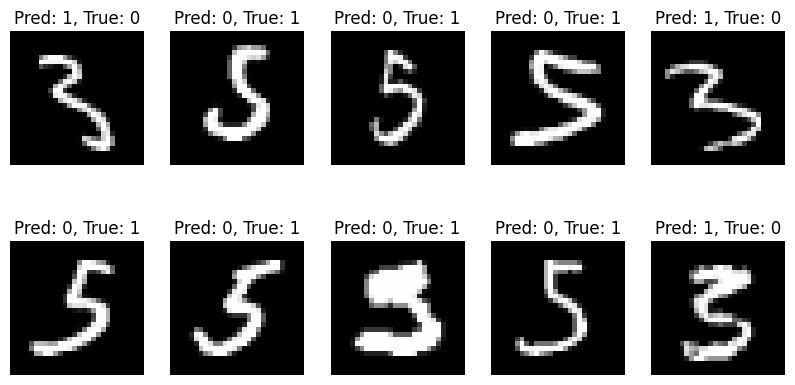

In [19]:
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X_35[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y_35[idx]}")
        ax.axis("off")

    plt.show()
else:
    print("All images were correctly classified!")

Conclusion:

The perceptron performs very well on 0 vs 1 classification with high accuracy.

For 3 vs 5 classification, the accuracy is lower.

This is because digits 3 and 5 are visually similar and harder to separate using a linear model.

The perceptron struggles with more complex patterns compared to simple ones.